# Assignment 3: Analysis of Local Track Discontinuities in Railway

## Laboration Participant
Viktor Lindberg || viklio-3@student.ltu.se 

## 1. Problem Description


Switches are an essential, safety-critical part of railway infrastructure. Compared to open tracks, their
complex geometry results in increased dynamic loading on the track superstructure caused by passing
trains, leading to higher maintenance costs. To improve efficiency, condition monitoring methods
specific to railway switches are necessary. A common approach to monitoring the track superstructure
is to measure the acceleration caused by vehicle-track interaction. Local interruptions in the wheel-
rail contact, caused by factors such as defects or track discontinuities, appear in the data as transient
impact events.

In this assignment, preprocessed data has been used to train two different machine learning/predictive model. The model is trained on common features between three different datasets (X) to predict whether an event will be either normal or abnormal (Y). The machine learning model is trained using an 80-20 split with two different methods. 

The first method: A standard 80-20 split, where the model tries to learn/find patterns whether an event is normal (0) or abnormal (1). The remaining 20 % of the data is used as a test set to see how well the model have learned and can adapt to data. 

The second method: The training data is split into 5 subsets. For each fold, 4 subsets are used to train the model and the remaining subset is used for validation. This process is repeated five times, so each subset is used once as validation. The results are averaged to provide a more stable estimate of model performance. 

After cross-validation we can use the results from the 5-fold-validation to tune/find optimal hyperparamters for our predictive model. Furthermore different feature selection methods have been used to find redundancy between features. The results showed 16 features can be reduced to 9 features without sacrificying any precision for the trained model.

## 2. General results and conclusions


The first method (80-20 train split without tuning) we can see that when testing the trained model on the testing data (the 20 % not used for training) we can see in the classification report precision = 1.00 for normal events. This means that every time a normal event was predicted it was correct. The precision for abnormal events = 0.90. This means that 10 % of our predicted abnormal events were actually normal. The overall accruacy for the model was 93 % and the results suggest that the model tend to predict more reliably to normal events compared to abnormal events.

The second method split the training data into 5 subsets. This method is often used to evaluate a model and tune a model based on different "hyperparameters". The cross-validation (cv) results show a mean CV score of 96.666 %, which represents the average performance across the 5 validation runs. This means that the when the model is tested on data not used for training, and it correctly predicts about 96.666 % of the predictions correctly (True prediction = true labeel). What this suggests is that our training data is quite consistent and reliable no matter what sets we choose to train on. 

Based on the results of the 5-fold validation, tuning of hyperparameters can be done to make the trained model generalize and predict more accurate. (Default for SVM_model, C = 1.0, Gamma = 1/NumberOfFeatures = 1/16 = 0,0625). The best hypermeters found based on 25 combinations (5*5):
- **Best hyperparameters from 5-fold CV: {'svc__C': 1, 'svc__gamma': 0.0625}**

This means the original 80-20 model is the best model based on the hyperparameters that was tested to optimize the model. This makes sense because the datasets consist of only 150 datasets, limiting the benefits of tuning. With more data and if the default model performed worse, hyperparameter tuning could potentially find parameters that improves the perdictability and generalization of the model.

Furthermore different feature selection techniques were tried to reduce redundancy between features and the target variable. 4 Different selection algorithms were tried:
- **2 Filter methods** (Pearson and MI) 
- **1 Wrapper method** (Recursive Feature Elimination, RFE)
- **1 Embedded method** (Lasso)

Checking the CV_scores for each method, resulted in the RFE method being the best with a mean CV_score of 95.33 % when choosing 6 features. After feature selection the following features was chosen:

- **kurtosis**, **min**, **crest_factor**, **zero_crossings**, **spectral_centroid**, **spectral_flatness**

Worth to note is that using the RFE, the highest possible CV_score (96.66 %) with the lowest amount of features was 9, meaning that 7/16 features either are redundant (measure the same thing as other features) or do not contribute to target variable Y (type of event). 

Besides the previous six features chosen, it also found that **range**, **skewness**, and **variance** should be included in the model to achieve the highest CV score with minimal set of features. 


## 3. Method and code

### 3.1 Import of used libraries

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline


import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

### 3.2 Reading and Merging the Data

In [46]:
# read the data file into dataframes and merge into one single dataframe for easier analysis
os.chdir("C:\\Users\\vikto\\Desktop\\Skola'\\Andra Kurser\\D7015B - Industrial AI and eMaintenence\\Assignment 3")
trail1 = pd.read_csv("trail1_data.csv")
trail2 = pd.read_csv("trail2_data.csv")
trail3 = pd.read_csv("trail3_data.csv")


In [47]:
#Merge the three trails into one DataFrame for easier analysis
merged_data = pd.concat([trail1, trail2, trail3], ignore_index=True)
print(merged_data.shape)
merged_data.drop(columns = ['start_time', 'axle', 'cluster', 'tsne_1', 'tsne_2'], inplace = True) #Drop the columns that are not needed for the analysis
merged_data["event"] = (merged_data["event"].str.lower() != "normal").astype(int) #Convert the event column to binary, where 0 = normal event and 1 is for any other event
print(merged_data.shape)

print(merged_data) #Verify data and check structure


(150, 22)
(150, 17)
             mean       std       max       min     range  skewness  \
0   -4.765466e-06  0.001350  0.007542 -0.006189  0.013731 -0.004788   
1   -5.524224e-06  0.024360  0.215148 -0.249093  0.464241 -0.036717   
2    1.592743e-05  0.003036  0.013389 -0.014713  0.028103 -0.058478   
3    6.701540e-05  0.024002  0.298642 -0.290638  0.589279  0.990779   
4   -1.478153e-04  0.008061  0.024657 -0.042391  0.067048 -0.331677   
..            ...       ...       ...       ...       ...       ...   
145  4.331390e-05  0.004245  0.011402 -0.018020  0.029422 -0.444835   
146 -1.099413e-05  0.005241  0.040248 -0.028953  0.069201  0.107682   
147  3.509744e-07  0.003042  0.010449 -0.012557  0.023006 -0.204318   
148 -1.468078e-05  0.002244  0.009144 -0.009182  0.018326  0.020199   
149  4.913164e-06  0.001840  0.008671 -0.009114  0.017785  0.058101   

      kurtosis       rms  crest_factor  variance  zero_crossings  \
0     0.472182  0.001350      5.587349  0.000002           

### 3.3 Method 1: Creating and analyzing 80-20 trained model


When normalizing the data, we want to exclude the event column since it is is a binary variable and we should only normalize features (X).
We will normalize only on the trained data (X_train) and then apply it to test_data (X_test) to not let the model have access to test data during training. This is important to prevent data leakage and ensure that the model generalizes well to unseen data. We want to normalize our data before analyzing it. This is to balance scaling between different feautures that might have different ranges and units.

#### 3.3.1 80-20 split to train and test data

In [48]:

X = merged_data.drop(columns=['event']) 
y = merged_data['event']


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, #y is the target variable (event) for training and testing.
                                                    test_size=0.2, #20 % of data for test and 80 % for training
                                                    random_state=42, 
                                                    stratify=y) #Same proportion of normal/abnormal events in both training and test sets


#### 3.3.2 Normalizing the data and training the svm_model

In [50]:

scaler = StandardScaler() #Standardscaler comes from sklearn.preproccing package and standardizes to N(0,1) distiribution
X_train_scaled = scaler.fit_transform(X_train) #Fit the scaler on the training data and transform it
X_test_scaled = scaler.transform(X_test) #Transform the test data using the same scaler fitted on the training data

svm_model = SVC(kernel='rbf', probability=True, random_state=42) #Create an SVM model with RBF kernel, random_state=42 basically means we can re-use the same seed
svm_model.fit(X_train_scaled, y_train) #Fit the SVM model on the scaled training data (80/20 split)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


#### 3.3.3 Testing the trained model on the test set

When testing the trained model we can visualize the results from the classification_report using a confusion_matrix. The results are explained in the first section of this report under general results and conclusion

              precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       0.90      1.00      0.95        18

    accuracy                           0.93        30
   macro avg       0.95      0.92      0.93        30
weighted avg       0.94      0.93      0.93        30



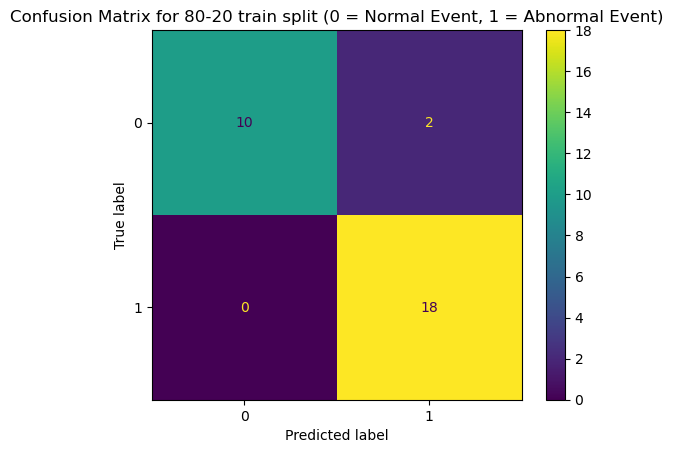

In [51]:

#Evaluate the model on the test set
y_pred = svm_model.predict(X_test_scaled) #Predict the labels for the test set using the trained SVM model

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_) 
disp.plot() #Plot the confusion matrix
plt.title("Confusion Matrix for 80-20 train split (0 = Normal Event, 1 = Abnormal Event)")
plt.show()

### 3.4 Method 2: 5-fold cross-validation split

5-fold cross-validation splits training data into 5 subsets, trains on 4 of these and test on remaining subsets, and repeats for each subset. This model is then used on test set to evaluate performance. 

#### 3.4.1 5-fold Cross-validation and Tuning of Hyperparameters

To do this make_pipeline is used from the skl.learn package. make_pipeline combines preprocessing + modeling into a single object which simplifies evalaution and hyperparameter tuning. This means when we perform our cross validation "cross_val_score" we can feed raw data that is normalized by the pipeline (see the first two lines of code.)

Then a grid_search is done to find whether there is any more suitable paramters for the predictive model (see parameter valeus in code)

The  mean CV_score of showed to be 96.666 %, which represents the average performance across the 5 validation runs. This means that the when the model is tested on data not used for training, and it correctly predicts about 96.666 % of the predictions correctly (True prediction = true labeel). What this suggests is that our training data is quite consistent and reliable no matter what sets we choose to train on.  

In [52]:

pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, random_state=42)) #Create a pipeline that includes standard scaling and new SVM model to train on. 
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print("CV scores:", cv_scores)
print("Mean CV score:", np.mean(cv_scores))

#Hyperparameter grid for RBF SVM
param_grid = { #Parameters to search over for tuning the SVM model. Total 5x5 = 25 combinations to evaluate over cv = 5 folds --> 25*5 = 125 total model fits to evaluate and compare.
    'svc__C': [0.1, 0.05, 1, 10, 50], #C regulates trade-off between training error and testing error. High C prioritize minimizing training errors (sensitive to outliers). Low C allows more training errors but can improve generalization.
    'svc__gamma': [0.01, 0.0625, 0.1, 0.5, 1] #Gamma describes how local training points influence other data points. High gamma means data points only affect nearby points, lower gamma means data points have further reach and thus higher weight on more distant points.
}

grid = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1) #Creates the searchgrid
grid.fit(X_train, y_train) #Fit grid to training data, this will evaluate all combinations of hyperparameters in param_grid using 5-fold cross-validation and find the best combination based on mean CV score.
grid.cv_results_
print("Best CV score:", grid.best_score_) #Best mean CV score across all hyperparameter combinations
#Best hyperparameters from CV
print("Best hyperparameters from 5-fold CV:", grid.best_params_)



CV scores: [0.95833333 1.         0.95833333 0.91666667 1.        ]
Mean CV score: 0.9666666666666668
Best CV score: 0.9666666666666668
Best hyperparameters from 5-fold CV: {'svc__C': 1, 'svc__gamma': 0.0625}


#### 3.4.2 Evaluation and training of new CV_model

Based on the best hyperparameters we can optimize our new CV_model. In this case the optimal hyperparameters from 5-fold CV was found to be C = 1 and gamma = 0.0625, which are the same that are used for the original SVC_model. For original model standard values are:
- **C = 1**
- **Gamma = 1/NumberOfFeatures = 1/16 = 0.0625**

This is why both trained models perform the same. If more data would be available to train and test the model, hyperparameterization would be more beneficial and likely to improve the performance of the predictive model - especially if the original model has low accuracy.

CV-Tuned SVM Performance on Test Set:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        12
           1       0.90      1.00      0.95        18

    accuracy                           0.93        30
   macro avg       0.95      0.92      0.93        30
weighted avg       0.94      0.93      0.93        30



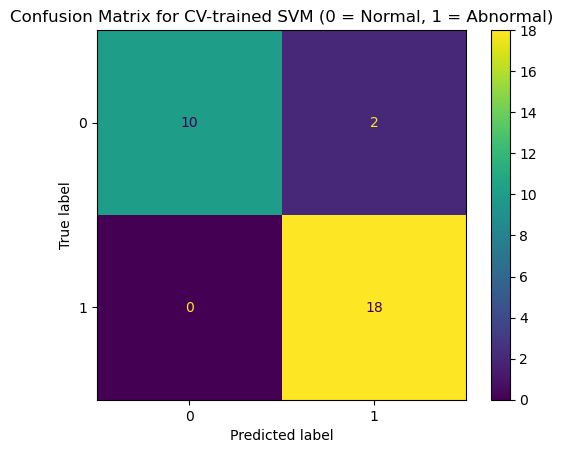

In [53]:

#Evaluate final CV-tuned model on test set
best_model = grid.best_estimator_
y_test_pred_cv = best_model.predict(X_test)

print("CV-Tuned SVM Performance on Test Set:")
print(classification_report(y_test, y_test_pred_cv)) 

cm_cv = confusion_matrix(y_test, y_test_pred_cv) #Compute the confusion matrix for trained cv model on test set
disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=best_model.named_steps['svc'].classes_)
disp_cv.plot()
plt.title("Confusion Matrix for CV-trained SVM (0 = Normal, 1 = Abnormal)")
plt.show()


## 4. Tasks for grade 5

### 4.1 Research of various feature selection techniques

"Feature selection is the process of choosing only the most useful input features for a machine learning model. It helps improve model performance, reduces noise and makes results easier to understand." (GeeksforGeeks, 2025) Currently I have another course within quality management, which includes using statistical analysis (two-level factorial design) to determine whether a variable have a significant effect on Y. For that course, we do not dwelve deeper into the different methods that are used to choose the msot useful input features, which is what this section will research deeper into. Feature selection can be classified into 2 main categories:
- **Supervised Techniques** - Used labeled data. They evaluate features based on their relationship with the target variable Y
- **Unsupervised Techniques** - Do not use labeled data. Select features based on properties such as variance, redundancy, or clustering quality. The aim here is to retain informative features without referencing to a target variable. Unsupervised does in other variables not include any specific target variable Y.

Good feature selection methods allow models to improve their accuracy - because they are only trained on important features it reduces white noise that might appear from features that in reality do not have an affect on the response variable (Y). The less features a model is trained on the less variables the model need to take into account when predicting which reduces computation time for predictions. The overall model also becomes easier to understand and reduces the overall complexity. 

For this assignment we want to study whether an event is abnormal or normal based on selected features. Different methods for feature selection can be
- **Filter Methods** - 
- **Wrapper Methods** - 
- **Embedded Methods** - 

This assignment will present 4 different selection algorithms. Section 4.1.1 - 4.1.3 presents theory behind the three methods and chosen selection algorithms for these to implement in python. The chosen selection algorithms are:

For Filter methods:
 - **Pearson correlation coefficient** - Objective to check for redundancy to inbetween feature and target variable
- **Mutual Information** - Complement Pearson correlation by finding non-linear relationships, as well as to which features / redundant features to remove

For Wrapper Method:
- **Recursive Feature Elimination** - Combines backward elimination and recursive training of model to eliminate non-important features. 

For Embedded Method:
- **Logistic Regression using L1 Penalty** -  Original Lasso is designed for regression - we want to use logistic regression using L1 Penalty to eliminate non-contributing features

Below is a quick comparison of the three different methods:

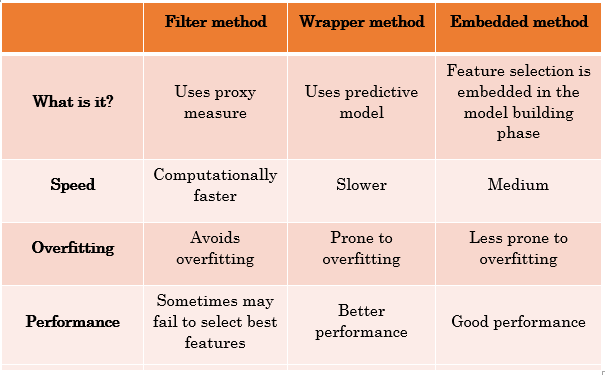

Comparison of three methods of feature selection (Data Sciences Machine Learning, 2019)

References: (Bajaj, 2021; Gupta, 2020; Holbrok & Cook, n.d. ; Data Sciences Machine Learning, 2019)

#### 4.1.1 Filter Methods

Filter methods evalaute each feature independently with the target variable. This makes it possible to identify features that have a high correlation with the target variable(s). Filter methods are used in the preprocessing phase to parse out irrelevant or redundant features based on different statistical tests. The main advantage with filter methods is that they are fast and efficient and easy to implement. This makes filter methods good for dealing with large datasets while keeping down compution costs.

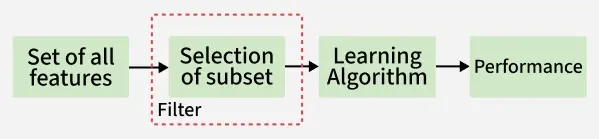

There is many filter techniques but this report will focus on:
- **Pearson's Correlation Coefficient**
- **Mutual Information Metric** - CONMI

It should be noted that even though filter methods can be advantageous, because they are simple and evaluate each feauture independently, filter methods to not consider relationships between multiple features (synergy effects). For some features they might only show significant effect when combined with another feature which filter effects will not pick up on and consequently incorrectly removing features that might have a significant impact on target variable Y.

References: (Bajaj, 2021; Duch, 2006; Holbrok & Cook, n.d.)


***Pearson's Correlation Coefficient***

Perason's correlation coefficient, r, quantifies the strength of association between 2 variables. In other words the linear relationship between these. For this assignment it means analyzing each feature independetly with target variable Y (abnormal or normal event). If there is a perfect positive linear relationship the coefficient, r = +1 and if it is perfect negative the coefficient, r = -1. The closer the coefficient r is to 0, the weaker linear relationship does the variable have with the target variable. One important limitation with this method is that it only investigates for linear relationships, meaning if the relationship between a variable and its target variable is for example exponential or quadratic, the pearson coefficient will most likely underestimate the strength of the relationship. Pearson's correlation coefficient can also be used to look at the correlation between different featurues, allowing to eliminate redundancy (features evaluating the same thing) (Steward, 2026). 

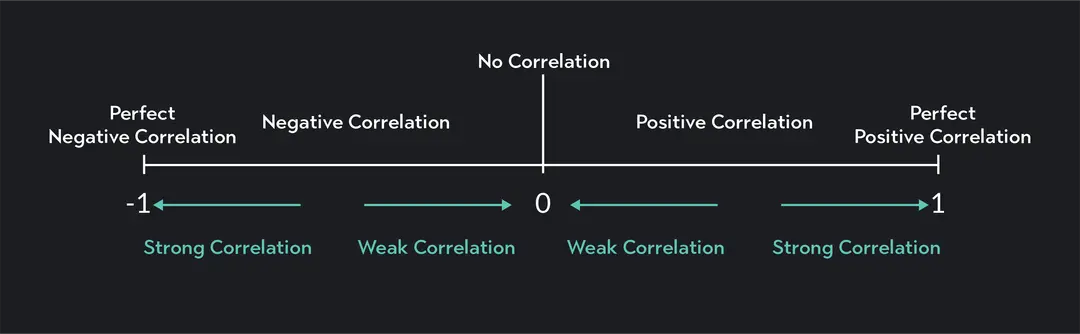
PictureFrom (Thomas, 2023)

References: (Steward, 2026; Thomas, 2023)


***Mutual Information Metric***

There is many definitions of what MI is (Zeng, 2015). For this report we will keep it simple:
- **MI measures how much knowing one variable reduces uncertainty about another.**
- **"Mutual Information measures how strongly a product and our decision are connected." (Rani, 2025).**
- **For this report: MI metric measures how informative a feature is about whether an event is normal or abnormal**
- **Mutual information metric is a metric that is always non-negative and measures how much information two variables share.**
- **Higher values indicate stronger dependancy.**
- **It is a logarithmic metric --> Increases slowly**


 
Below is a visualisation of MI and Tan idea of how MI values correspond to the kind and degree of association a feature has with the target.


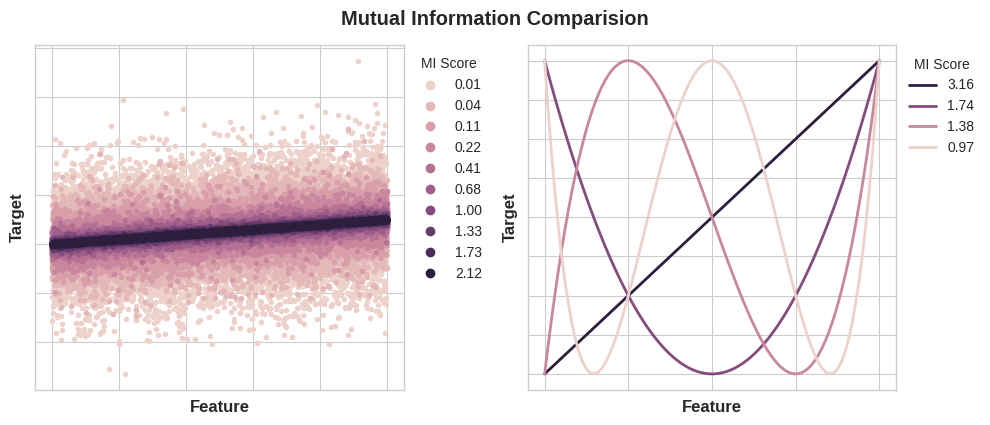

Left: Mutual information increases as the dependence between feature and target becomes tighter. Right: Mutual information can capture any kind of association (not just linear, like correlation.) (Holbrok & Cook, n.d.) 


References: (Holbrok & Cook, N.D; Kushaba 2022; Zeng, 2015; Rani, 2025)

#### 4.1.2 Wrapper Method - Recursive Feature Elimination

A wrapper method in context of feature selection that selects the best features by repeatedly training and evaluating a machine learning model. Wrapper methods take more computing power compared to filter methods. The reason for this is because wrapper methods try a combination of features to evaluate the model performance on our dataset, meanwhile in filter methods the feature selection is purely based on statistical data and do not involve training a statistical model. **Forward selection**, **Backward elimination**, and **Recursive Feature Elimination** are all popular wrapper techniques. For this report we will test the performance of using Recursive Feature Elimination (RFE)

***Recursive Feature Elimination (RFE)***

RFE is a combination of backward elimination with a recursive approach. *Backward elimination* works in the way that it starts with all the features and removes one feature at a time, and at each step removes the feature with the least importance. It does this until the models performance starts to degrade. **RFE** works like *backward elimination*, but each time a feature is removed, it retrains the model, and retrains the model until the desired number of features is reached. Below, the diagram visualizes the RFE process:

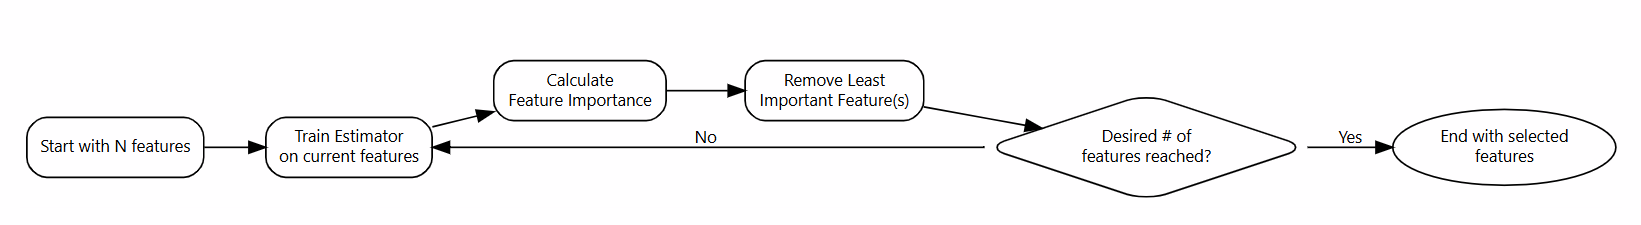
The iterative process of Recursive Feature Elimination (RFE). (APXML, n.d.)

The RFE trains the model based on a estimator. For this assignment a linear SVM model is used, because **RFE** relies on the model being able to rank features by its importance. A linear SVM allows this to be done in a simple way. Below is a comparison between how linear SVM vs non-linear SVM classifies data

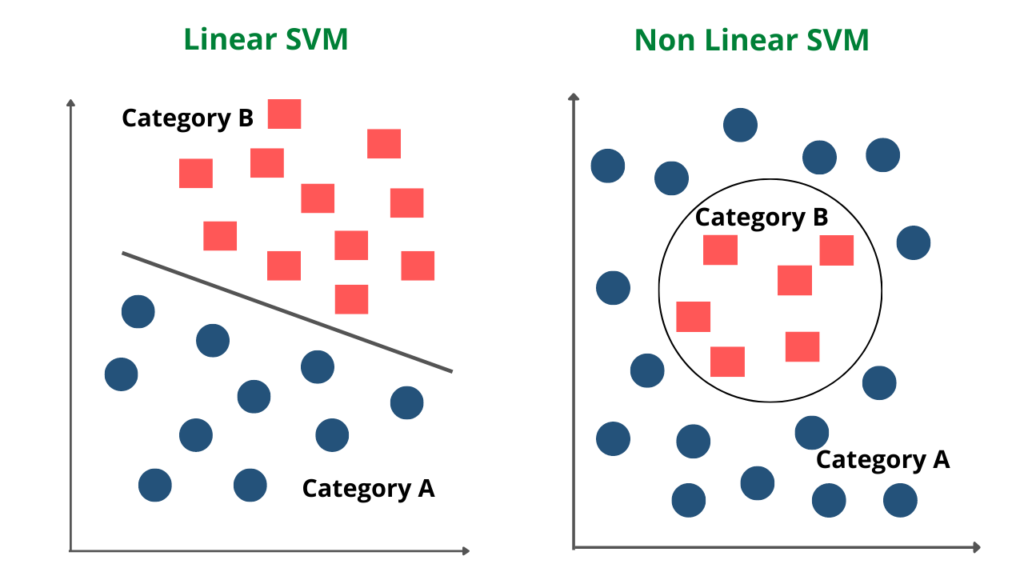
Categorization_of_data: Linear vs non-Linear SVM (Nattapoj, 2024)

References: (Bajaj, 2021; GeeksforGeeks, 2025 ; APXML, n.d ; Nattapoj, 2024), 

#### 4.1.3 Embedded Method - Logistic Regression using L1 Penalty

In embedded methods, the feature selection is built into the model training process itself. With Filter methods the model chose relevant features before training a model, for wrapper the model was retrained for each time a feature was deleted, but for embedded methods the algorithm automatically learns which features are important during training. Embedded methods provides an inbetween between filter and wrapper methods for training. It is more accurate than filter methods because feature importance is determined in relation to the model being trained. The embedded methods are also faster than wrapper methods since the model does not need to be retrained for each elimination. For this assignment, where we only train on 150 data points this is not so noticable, but if we would have thousands of data points to analyze with many features to select from retraining the model would become computionally expensive and thus a embedded method justified - trading some accuracy for faster computation. For this assignment we will combine logistic regression using L1 Penalty

**Logistic Regression using L1 Penalty Embedded Method**

For regularization the idea is to minimize a loss function. However only minimizng a loss function can lead to a model trying to overfit the data, meaning it tries to fitting the data too perfectly on training data, causing it to instead perform poorer on unseen data. To solve this s penalty term. The model then tries to minimize:

- **Loss Function + Penalty Term**, where the loss functions describes how inaccuraty predictions are (error between predictions and actual answers), and penalty to disencourage overly complex models (without penalty term, if a model tries to minimize the loss function, it may try to fit training data too perfectly leading to overfitting). In mathematical terms, this can generalized to:

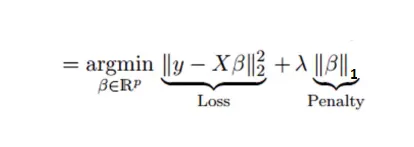

Generalization of object function Loss + Penalty terms (Depala 2025)

For this assignment we will Lasso (L1) Penalty. Classic Lasso regression aims to predict numeric targets, but since for this assignment the target variable is chategorical (trying to predict normal vs abnormal events), logistic regression using L1 penalty is used instead. The idea with L1 Penalty is to penalize features that have no or low impact on the target variable (Y) by increase its alpha coefficient. A higher alpha coefficient means a higher penalty, making coefficients more likely to be shrunk to zero, and consequently the model simpler as more features are removed.

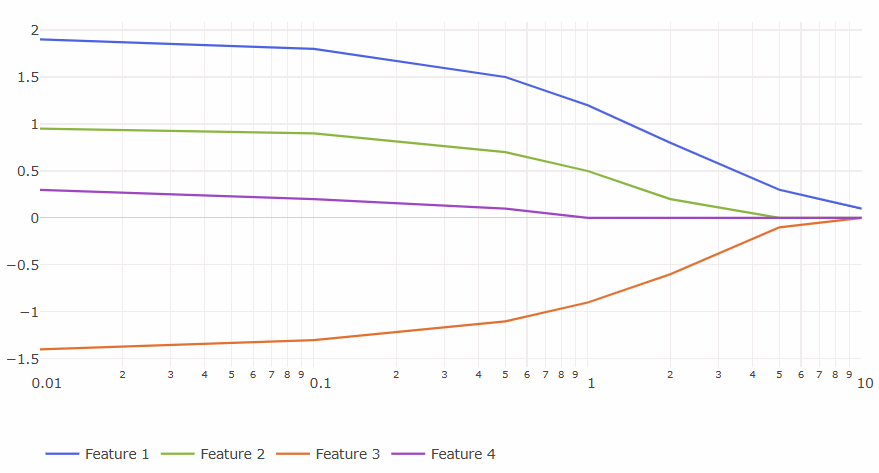

Illustration of how Lasso coefficients change as the regularization strength (alpha) increases. (ApX Machine Learning, n.d.)

In summary logistic regression with L1 penalty simultaneously learns to predict and select important features. During training, the model tries to adjust its coefficients to make accurate predictions (minimizing error) while at the same time the L1 penalty pushes some coefficients to zero if they have a low impact (penalized) and are eventually removed.


References: (ApX Machine Learning, n.d. ; Depala, 2025; Data Sciences Machine Learning, 2019; scikit-learn, n.d)

#### 4.1.4 Sources used for research

Bajaj, R. (2021). Feature selection techniques in machine learning. Geeks for Geeks. From:
https://www.geeksforgeeks.org/machine-learning/feature-selection-techniques-in-machine-learning/

Gupta, A. (2020). Feature selection techniques in machine learning. Analytics Vidhya. From:
https://www.analyticsvidhya.com/blog/2020/10/feature-selection-techniques-in-machine-learning/

Duch, W. (2006). Filter methods. In Feature extraction: foundations and applications (pp. 89-117). Berlin, Heidelberg: Springer Berlin Heidelberg. From:
https://link.springer.com/chapter/10.1007/978-3-540-35488-8_4

Stewart, K. (2026, February 13). Pearson’s correlation coefficient. Encyclopedia Britannica. From:
https://www.britannica.com/topic/Pearsons-correlation-coefficient

Thomas, S. (2023, April 11). Understanding the Pearson correlation coefficient. Outlier. From:
https://articles.outlier.org/pearson-correlation-coefficient

Kushaba, R. (2022, January 7). Entropy & Mutual Information in Machine Learning [Video]. From:
https://www.youtube.com/watch?v=YKDZHPJ-pQ0

Rani, R. (2025, December 20). Filter methods in feature selection: Simplify data to boost machine learning performance. Medium. From:
https://medium.com/@richa.insights/filter-methods-in-feature-selection-simplify-your-dataset-for-faster-machine-learning-e4d71b474ff0

Zeng, G. (2015). A unified definition of mutual information with applications in machine learning. Mathematical Problems in Engineering, 2015(1), 201874. From:
https://onlinelibrary.wiley.com/doi/full/10.1155/2015/201874

Holbrook, R., Cook, A. (N.D). Mutual Information. Kaggle. From: 
https://www.kaggle.com/code/ryanholbrook/mutual-information

GeeksforGeeks. (2025, July 23). Wrapper methods for feature selection in machine learning. GeeksforGeeks. From:
https://www.geeksforgeeks.org/machine-learning/wrapper-methods-feature-selection/

APXML. (n.d.). Wrapper methods and recursive feature elimination (RFE). APXML. From:
https://apxml.com/courses/intro-feature-engineering/chapter-6-feature-selection/wrapper-rfe

Nattapoj, A. P. (2024, March 6). Basic comparison between Random Forest, SVM, and XGBoost. Medium. From:
https://medium.com/@ap.nattapoj_st/basic-comparison-between-randomforest-svm-and-xgboost-0e5862871175)

Data Sciences Machine Learning. (2019, October). Feature selection: Filter method, wrapper method and embedded method. From:
https://www.datasciencesmachinelearning.com/2019/10/feature-selection-filter-method-wrapper.html

Lal, T. N., Chapelle, O., Weston, J., & Elisseeff, A. (2006). Embedded methods. In Feature extraction: Foundations and applications (pp. 137-165). Berlin, Heidelberg: Springer Berlin Heidelberg. From:
https://link.springer.com/chapter/10.1007/978-3-540-35488-8_6

ApX Machine Learning. (n.d.). Lasso (L1) regularization. ApXML. From: 
https://apxml.com/courses/intro-feature-engineering/chapter-6-feature-selection/embedded-lasso-l1

Depala, R. (2025, October 14). Regularization in machine learning & deep learning (Part 1). Medium. From:
https://medium.com/@rajeswaridepala/regularization-in-machine-learning-8826072e3df5

scikit‑learn. (n.d.). Generalized linear models
https://scikit-learn.org/stable/auto_examples/linear_model/index.html


### 4.2 Practical Implementation in Python of 2 Filter Methods

The final conclusion of the filter methods are that from 16 features, the features kept after redundant features are removed are as well as features with no significant impact on type of event are:
- **Kurtosis** with the highest correleation 
- **max** 
- **zero_crossings** 
- **spectral_flatness** 
- **skewness** 
- **spectral_bandwith** 

In [54]:
#Separate features and target
X = merged_data.drop(columns=['event'])
y = merged_data['event']

#### 4.2.1 Pearson Correleation Matrix

Below is the code for the pearson correleation matrix. Here we can analyze linear relationships between features to eliminate redundancy  target variable "event" to remove features that have no impact on type of event. Highly correleated features were removed (pearson score > 0.9, and the one with the highest MI scores were are kept)
Redundancy can be found for:
- **max** and **min** (0.952730)
- **spectral_centroid** and **spectral_flatness** (r = 0.9724)
- **kurtosis** and **crest_factor** (r = 0.9103)
- **std** and **max** (r = 0.9282)
- **variance** and **max** (r = 0.9216)
- **rms** and **max** (r = 0.9282)
- **spectral_energy** and **max** (r = 0.9161)
- **range** and **max** (r = 0.9894)

What can be noted here is that many of the features have strong correleation with **max**, implying they all measure the same physical property, amplitude. 

Remaining features that are found to not be redundant with other features:
- **skewness**
- **zero_crossings**
- **dominant_frequency**
- **spectral bandwith**
- **mean**


From the pearson correleation relationship a few linear relationships are found between feature and event:
- **crest_factor** (relationship 0.77 --> likely to follow linear relationship).

There is more features that can be suspected to have a linear relationship (r-value around +-0.5) with **event**, but we will determine the most important when computing the mutual information scores for each feature with event (that way we can also identify potential non-linear relationships). Based on features mutual scores, features to keep for the new model will be selected. In terms of redundancy, the feature with the highest score between the two will be kept.




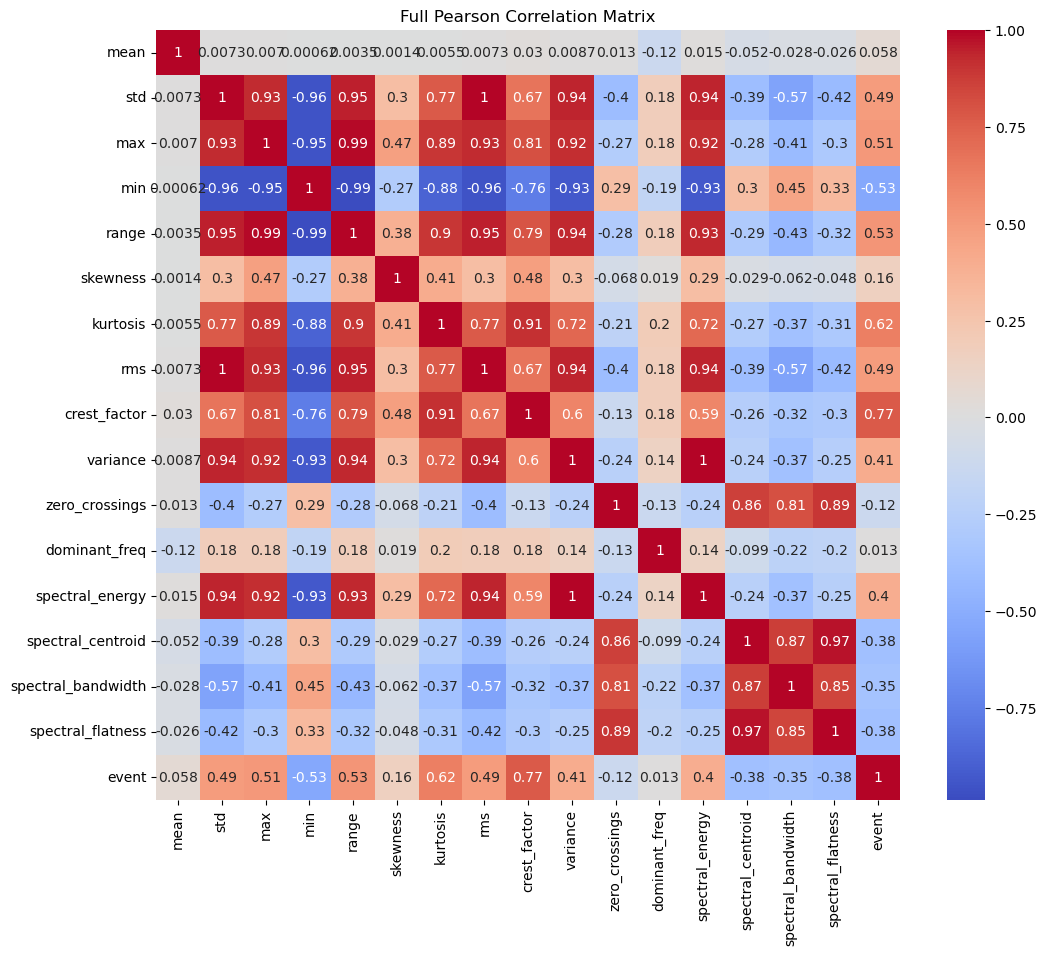

In [55]:
corr_matrix = merged_data.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Full Pearson Correlation Matrix")
plt.show()

#### 4.2.2 Mutual Information Metric - Eliminating Indentified Redundancy and Non-significant Features

From the mutual information metric graph we can datermine that for redundancy, the feature with the highest score is kept between the two:
- **max** and **min**, max is kept 
- **spectral_centroid** and **spectral_flatness**, spectral flatness is kept
- **kurtosis** and **crest_factor**, kurtosis is kept
- **std** and **max**, max is kept
- **variance** and **max**, max is kept
- **rms** and **max**, max is kept
- **spectral_energy** and **max**, max is kept
- **range** and **max**, max is kept

All the features displaying redundancy display an MI_score above 0.1. Features with a low MI_score (less than 0.15) are also removed. Out of the features not showing redundancy the following can be shown through the mutual information diagram:
- **skewness** is kept (MI_score around 0.21)
- **zero_crossings** is kept (MI_score around 3.1)
- **spectral_bandwith** is kept (MI_score around 0.19)
- **dominant_frequency** is removed (MI_score around 1.1)
- **mean** is removed (MI_score below 0.1)

So from 16 features, the features kept after redundant features are removed are as well as features with a low MI_score are:
- **Kurtosis** with the highest correleation (MI_score 0.6)
- **max** (MI_score = 0.33)
- **zero_crossings** (MI_score 0.31)
- **spectral_flatness** (MI_score 0.23)
- **skewness** (MI_score 0.21)
- **spectral_bandwith** (MI_score 0.19)

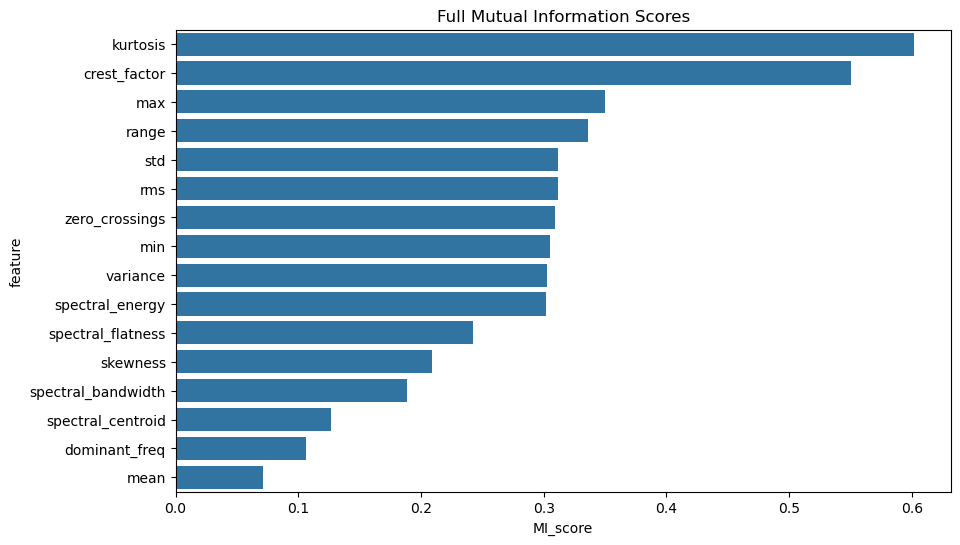

In [56]:
#Mutual Information scores for all features
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'feature': X.columns, 'MI_score': mi_scores}).sort_values(by='MI_score', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='MI_score', y='feature', data=mi_df)
plt.title("Full Mutual Information Scores")
plt.show()

### 4.3 Practical Implementation of Wrapper Method: Recursive Feature Elimination

In [57]:
svc_estimator = SVC(kernel='linear', random_state=42)  # linear kernel. Might miss non-linear relationships.
rfe = RFE(estimator=svc_estimator, n_features_to_select=6)  # choose 6 features
pipeline_rfe = make_pipeline(StandardScaler(), rfe, svc_estimator)
pipeline_rfe.fit(X, y)
selected_features_rfe = X.columns[rfe.support_].tolist()
print("RFE selected features:", selected_features_rfe)

RFE selected features: ['min', 'kurtosis', 'crest_factor', 'zero_crossings', 'spectral_centroid', 'spectral_flatness']


### 4.4 Practical Implementation of Embedded Method: Logistic Regression with L1 Penalty

In [58]:
pipeline_logregL1 = make_pipeline(
    StandardScaler(),
    LogisticRegression(penalty='l1', solver='liblinear', C = 1.0,random_state=42) #C = 1/alpha, where alpha is penalty strength (regularization parameter). Read more about this in research section of report.
)

pipeline_logregL1.fit(X, y)

coef = pipeline_logregL1.named_steps['logisticregression'].coef_[0]
selected_features_l1 = X.columns[coef != 0].tolist()

print("\nLASSO selected features:", selected_features_l1)


LASSO selected features: ['crest_factor', 'variance', 'zero_crossings', 'dominant_freq', 'spectral_centroid', 'spectral_flatness']


### 4.5 Summary and Comparisson of the Results

Below is a table summarizing the results of each method used (Filter - Pearson + MI, Wrapper - RFE, Embedded - Logistics regression with L1 penalty)

| Feature (6 selected)| Filter | RFE  | LogReg (L1) |
|--------------------|:------:|:----:|:-----:|
| kurtosis           | Yes     | Yes  | No  |
| max                | Yes     | No    | No    | 
| min                | No    | Yes   | No    | 
| crest_factor       | No     | Yes  | Yes    | 
| zero_crossings     | Yes     | Yes  | Yes    | 
| spectral_centroid  | No    | Yes  | Yes   |
| spectral_flatness  | Yes     | Yes  | Yes    | 
| skewness           | Yes    | No  | No    | 
| spectral_bandwidth | Yes    | No   | No    |
| variance           | No      | No   | Yes     |
| dominant_freq      | No       | No    | Yes

From the table we can see that features like zero crossings and spectral flatness are have an significant enough impact on target variable, event, no matter what feature selection method is used. To further analyze which method works the best with our data set, we can use 5-fold validation like done previously when training a model on all the 16 features. This allows us to compare the accuracy and stability of each methods.

In [59]:
filter_features = ['kurtosis', 'max', 'zero_crossings', 'spectral_flatness', 'skewness', 'spectral_bandwidth']
rfe_features = selected_features_rfe
lasso_features = selected_features_l1

X_filter = X[filter_features]
X_rfe = X[rfe_features]
X_lasso = X[lasso_features]

def evaluate_features(X_sub, y):
    pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, random_state=42))
    scores = cross_val_score(pipeline, X_sub, y, cv=5)
    mean_score = float(np.mean(scores))
    return mean_score


Filter_Score = evaluate_features(X_filter, y)
print("Filter features performance:", Filter_Score)

RFE_Score = evaluate_features(X_rfe, y)
print("RFE features performance:", RFE_Score)

LASSO_Score = evaluate_features(X_lasso, y)
print("LASSO features performance:", LASSO_Score)


Filter features performance: 0.9199999999999999
RFE features performance: 0.9533333333333334
LASSO features performance: 0.9400000000000001


The results perform as expected. From the research about the three different methods (Filter, Wrapper, and Embedded). The filter methods have the lowest accuracy of around 92 % (lowest demand in compution power), the embedded in the middle with an accuracy of around 94 % (low-mid demand in computation power) and finally the wrapper method (RFE) with the highest accuracy when selecting only 6 features of 95.333 % (high demand in computation power).

This suggests that RFE provides the best predictability for this dataset of the tested methods. This is quite likely because the RFE method tests for synergies (how different features together target Y) that the other two methods miss. It also retrains the model after one feature is removed providing better accuracy (explained more in the research section). Worth to note is that by reducing redundancy and features the model needs to predict Y, the predictability decreases (by around 1 %, from 96.66 % using all the features). This however can be a valid tradeoff for organizations as the model becomes easier to understand, reduces computing time/power, and more maintainable. I did also try to change the selected features for the RFE to find the optimal number of features to achieve the highest mean CV score. This ended up being 9 features giving a CV score of 96.66 %. This means out of our dataset, we can conclude that out of 16 features, 7 of them are either redundant or do not contribute to target variable Y (type of event).